In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

FEATURE_ROOT = "/content/drive/MyDrive/music-genre-capstone/data/features"

print("Feature root:")
print(FEATURE_ROOT)

print("\nContents:")
print(os.listdir(FEATURE_ROOT))

Feature root:
/content/drive/MyDrive/music-genre-capstone/data/features

Contents:
['train', 'validation', 'test', 'training', 'training_final', 'validation_final', 'test_final']


In [ ]:
for split in ["training_final", "validation_final", "test_final"]:
    split_path = os.path.join(FEATURE_ROOT, split)

    files = os.listdir(split_path)

    print(f"\n{split}")
    print(f"Total files: {len(files)}")
    print("First 10 files:")

    for filename in sorted(files)[:10]:
        print(" ", filename)


training_final
Total files: 40
First 10 files:
  shard_000.npz
  shard_001.npz
  shard_002.npz
  shard_003.npz
  shard_004.npz
  shard_005.npz
  shard_006.npz
  shard_007.npz
  shard_008.npz
  shard_009.npz

validation_final
Total files: 7
First 10 files:
  checkpoints
  shard_000.npz
  shard_001.npz
  shard_002.npz
  shard_003.npz
  shard_004.npz
  shard_005.npz

test_final
Total files: 7
First 10 files:
  checkpoints
  shard_000.npz
  shard_001.npz
  shard_002.npz
  shard_003.npz
  shard_004.npz
  shard_005.npz


In [ ]:
import numpy as np

training_path = os.path.join(FEATURE_ROOT, "training_final")
sample_shard = os.path.join(training_path, "shard_000.npz")

data = np.load(sample_shard)

print("Shard:", sample_shard)
print("\nKeys:")
print(data.files)

print("\nContents:")
for key in data.files:
    print(f"{key}:")
    print("  Shape:", data[key].shape)
    print("  Dtype:", data[key].dtype)

Shard: /content/drive/MyDrive/music-genre-capstone/data/features/training_final/shard_000.npz

Keys:
['track_id', 'genre', 'ann_features', 'mel_features']

Contents:
track_id:
  Shape: (500,)
  Dtype: int64
genre:
  Shape: (500,)
  Dtype: <U13
ann_features:
  Shape: (500, 80)
  Dtype: float32
mel_features:
  Shape: (500, 128, 1292)
  Dtype: float16


In [ ]:
genres = data["genre"]

unique_genres = np.unique(genres)

print("Number of unique genres:", len(unique_genres))
print("\nGenres:")

for genre in unique_genres:
    print(genre)

Number of unique genres: 10

Genres:
Country
Electronic
Experimental
Folk
Hip-Hop
International
Jazz
Pop
Rock
Spoken


In [ ]:
for split in ["training_final", "validation_final", "test_final"]:
    split_path = os.path.join(FEATURE_ROOT, split)

    print(f"\n{'=' * 50}")
    print(split)
    print(f"{'=' * 50}")

    for filename in sorted(os.listdir(split_path)):
        if filename.endswith(".npz"):
            shard_path = os.path.join(split_path, filename)

            shard = np.load(shard_path)

            print(f"\n{filename}")
            print("Keys:", shard.files)


training_final

shard_000.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_001.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_002.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_003.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_004.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_005.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_006.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_007.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_008.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_009.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_010.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_011.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_012.npz
Keys: ['track_id', 'genre', 'ann_features', 'mel_features']

shard_01

In [ ]:
for split in ["validation_final", "test_final"]:
    split_path = os.path.join(FEATURE_ROOT, split)

    print(f"\n{'=' * 50}")
    print(split)
    print(f"{'=' * 50}")

    for filename in sorted(os.listdir(split_path)):
        if filename.endswith(".npz"):
            shard_path = os.path.join(split_path, filename)

            shard = np.load(shard_path)

            print(f"{filename}: {shard.files}")


validation_final
shard_000.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_001.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_002.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_003.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_004.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_005.npz: ['track_id', 'genres', 'ann_features', 'mel_features']

test_final
shard_000.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_001.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_002.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_003.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_004.npz: ['track_id', 'genres', 'ann_features', 'mel_features']
shard_005.npz: ['track_id', 'genres', 'ann_features', 'mel_features']


In [ ]:
from collections import Counter

split_label_keys = {
    "training_final": "genre",
    "validation_final": "genres",
    "test_final": "genres"
}

for split in ["training_final", "validation_final", "test_final"]:
    split_path = os.path.join(FEATURE_ROOT, split)
    label_key = split_label_keys[split]

    all_genres = []

    for filename in sorted(os.listdir(split_path)):
        if filename.endswith(".npz"):
            shard_path = os.path.join(split_path, filename)

            shard = np.load(shard_path)
            genres = shard[label_key]

            for genre in genres:
                all_genres.append(str(genre))

    counts = Counter(all_genres)

    print(f"\n{'=' * 50}")
    print(split)
    print(f"{'=' * 50}")
    print("Total tracks:", len(all_genres))
    print("Number of classes:", len(counts))

    print("\nClass distribution:")
    for genre in sorted(counts):
        print(f"{genre}: {counts[genre]}")


training_final
Total tracks: 19909
Number of classes: 16

Class distribution:
Blues: 58
Classical: 495
Country: 142
Easy Listening: 13
Electronic: 5048
Experimental: 1800
Folk: 1214
Hip-Hop: 1757
Instrumental: 1044
International: 814
Jazz: 306
Old-Time / Historic: 408
Pop: 945
Rock: 5677
Soul-RnB: 94
Spoken: 94

validation_final
Total tracks: 2504
Number of classes: 16

Class distribution:
Blues: 8
Classical: 62
Country: 18
Easy Listening: 2
Electronic: 631
Experimental: 225
Folk: 152
Hip-Hop: 220
Instrumental: 131
International: 102
Jazz: 39
Old-Time / Historic: 51
Pop: 122
Rock: 711
Soul-RnB: 18
Spoken: 12

test_final
Total tracks: 2572
Number of classes: 16

Class distribution:
Blues: 8
Classical: 62
Country: 18
Easy Listening: 6
Electronic: 632
Experimental: 225
Folk: 152
Hip-Hop: 220
Instrumental: 174
International: 102
Jazz: 39
Old-Time / Historic: 51
Pop: 119
Rock: 710
Soul-RnB: 42
Spoken: 12


In [ ]:
class_names = [
    "Blues",
    "Classical",
    "Country",
    "Easy Listening",
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Jazz",
    "Old-Time / Historic",
    "Pop",
    "Rock",
    "Soul-RnB",
    "Spoken"
]

label_to_index = {}

for index, class_name in enumerate(class_names):
    label_to_index[class_name] = index

print("Number of classes:", len(class_names))
print("\nLabel mapping:")

for class_name in class_names:
    print(f"{class_name}: {label_to_index[class_name]}")

Number of classes: 16

Label mapping:
Blues: 0
Classical: 1
Country: 2
Easy Listening: 3
Electronic: 4
Experimental: 5
Folk: 6
Hip-Hop: 7
Instrumental: 8
International: 9
Jazz: 10
Old-Time / Historic: 11
Pop: 12
Rock: 13
Soul-RnB: 14
Spoken: 15


In [ ]:
def load_ann_data(split_name):
    split_path = os.path.join(FEATURE_ROOT, split_name)

    if split_name == "training_final":
        label_key = "genre"
    else:
        label_key = "genres"

    all_features = []
    all_labels = []

    for filename in sorted(os.listdir(split_path)):
        if filename.endswith(".npz"):
            shard_path = os.path.join(split_path, filename)

            shard = np.load(shard_path)

            features = shard["ann_features"]
            genres = shard[label_key]

            all_features.append(features)

            for genre in genres:
                all_labels.append(label_to_index[str(genre)])

    X = np.concatenate(all_features, axis=0)
    y = np.array(all_labels, dtype=np.int64)

    return X, y

In [ ]:
X_train, y_train = load_ann_data("training_final")
X_val, y_val = load_ann_data("validation_final")
X_test, y_test = load_ann_data("test_final")

print("Training:")
print("  Features:", X_train.shape)
print("  Labels:", y_train.shape)

print("\nValidation:")
print("  Features:", X_val.shape)
print("  Labels:", y_val.shape)

print("\nTest:")
print("  Features:", X_test.shape)
print("  Labels:", y_test.shape)

Training:
  Features: (19909, 80)
  Labels: (19909,)

Validation:
  Features: (2504, 80)
  Labels: (2504,)

Test:
  Features: (2572, 80)
  Labels: (2572,)


In [ ]:
print("Checking ANN features...")

print("\nTraining:")
print("NaN:", np.isnan(X_train).sum())
print("Inf:", np.isinf(X_train).sum())

print("\nValidation:")
print("NaN:", np.isnan(X_val).sum())
print("Inf:", np.isinf(X_val).sum())

print("\nTest:")
print("NaN:", np.isnan(X_test).sum())
print("Inf:", np.isinf(X_test).sum())

print("\nLabel ranges:")
print("Training:", y_train.min(), "to", y_train.max())
print("Validation:", y_val.min(), "to", y_val.max())
print("Test:", y_test.min(), "to", y_test.max())

Checking ANN features...

Training:
NaN: 0
Inf: 0

Validation:
NaN: 0
Inf: 0

Test:
NaN: 0
Inf: 0

Label ranges:
Training: 0 to 15
Validation: 0 to 15
Test: 0 to 15


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn scaling values only from training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaling to validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training scaled shape:", X_train_scaled.shape)
print("Validation scaled shape:", X_val_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

print("\nTraining feature statistics:")
print("Mean:", X_train_scaled.mean())
print("Standard deviation:", X_train_scaled.std())

Training scaled shape: (19909, 80)
Validation scaled shape: (2504, 80)
Test scaled shape: (2572, 80)

Training feature statistics:
Mean: 1.2789746e-09
Standard deviation: 1.0


In [ ]:
import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Training features:", X_train_tensor.shape)
print("Training labels:", y_train_tensor.shape)

print("Validation features:", X_val_tensor.shape)
print("Validation labels:", y_val_tensor.shape)

print("Test features:", X_test_tensor.shape)
print("Test labels:", y_test_tensor.shape)

Training features: torch.Size([19909, 80])
Training labels: torch.Size([19909])
Validation features: torch.Size([2504, 80])
Validation labels: torch.Size([2504])
Test features: torch.Size([2572, 80])
Test labels: torch.Size([2572])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 156
Validation batches: 20
Test batches: 21


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Training device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available. Training will use CPU.")

Training device: cuda
GPU: Tesla T4


In [ ]:
import torch.nn as nn

class ANN(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# Create the model
model = ANN(
    input_size=80,
    num_classes=16
)

# Move the model to the GPU
model = model.to(device)

print(model)

ANN(
  (network): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
)


In [ ]:
import torch.optim as optim

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer for updating model weights
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for features, labels in train_loader:

        # Move data to the GPU
        features = features.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Make predictions
        outputs = model(features)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Calculate gradients
        loss.backward()

        # Update model weights
        optimizer.step()

        # Track loss
        total_loss += loss.item() * features.size(0)

        # Find predicted class
        predictions = outputs.argmax(dim=1)

        # Count correct predictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [ ]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for features, labels in data_loader:

            # Move data to the GPU
            features = features.to(device)
            labels = labels.to(device)

            # Make predictions
            outputs = model(features)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Track loss
            total_loss += loss.item() * features.size(0)

            # Find predicted class
            predictions = outputs.argmax(dim=1)

            # Count correct predictions
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [ ]:
import time

num_epochs = 20

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

training_time = time.time() - start_time

print(f"\nTotal training time: {training_time:.2f} seconds")

Epoch 01/20 | Train Loss: 1.6992 | Train Acc: 0.4905 | Val Loss: 1.3833 | Val Acc: 0.5779
Epoch 02/20 | Train Loss: 1.3744 | Train Acc: 0.5773 | Val Loss: 1.3146 | Val Acc: 0.5966
Epoch 03/20 | Train Loss: 1.3053 | Train Acc: 0.5952 | Val Loss: 1.2771 | Val Acc: 0.6086
Epoch 04/20 | Train Loss: 1.2613 | Train Acc: 0.6065 | Val Loss: 1.2681 | Val Acc: 0.6102
Epoch 05/20 | Train Loss: 1.2316 | Train Acc: 0.6144 | Val Loss: 1.2586 | Val Acc: 0.6114
Epoch 06/20 | Train Loss: 1.2040 | Train Acc: 0.6198 | Val Loss: 1.2826 | Val Acc: 0.6082
Epoch 07/20 | Train Loss: 1.1818 | Train Acc: 0.6280 | Val Loss: 1.2732 | Val Acc: 0.6142
Epoch 08/20 | Train Loss: 1.1557 | Train Acc: 0.6323 | Val Loss: 1.2774 | Val Acc: 0.6082
Epoch 09/20 | Train Loss: 1.1369 | Train Acc: 0.6383 | Val Loss: 1.2498 | Val Acc: 0.6262
Epoch 10/20 | Train Loss: 1.1169 | Train Acc: 0.6433 | Val Loss: 1.2643 | Val Acc: 0.6158
Epoch 11/20 | Train Loss: 1.0986 | Train Acc: 0.6496 | Val Loss: 1.2790 | Val Acc: 0.6126
Epoch 12/2

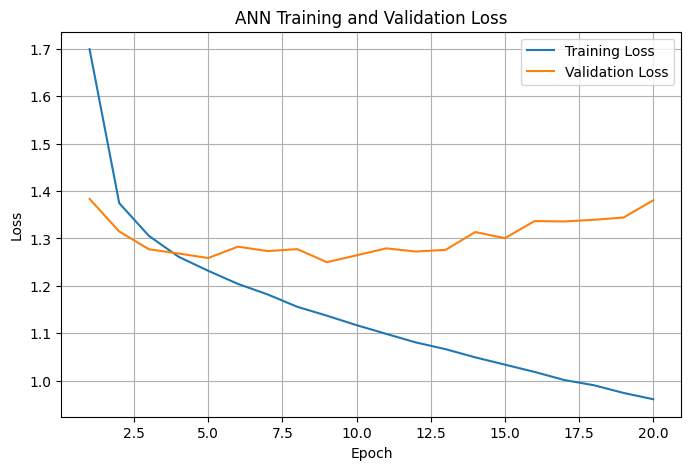

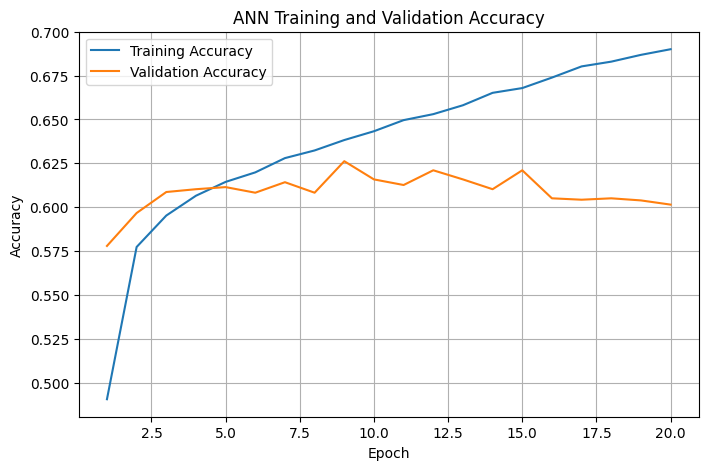

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

# Plot loss
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


# Plot accuracy
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_epoch = 0
best_val_accuracy = 0.0

for epoch in range(num_epochs):

    if val_accuracies[epoch] > best_val_accuracy:
        best_val_accuracy = val_accuracies[epoch]
        best_epoch = epoch

print("Best epoch:", best_epoch + 1)
print("Best validation accuracy:", best_val_accuracy)

print("\nValidation loss at best epoch:", val_losses[best_epoch])
print("Training accuracy at best epoch:", train_accuracies[best_epoch])
print("Training loss at best epoch:", train_losses[best_epoch])

Best epoch: 9
Best validation accuracy: 0.6261980830670927

Validation loss at best epoch: 1.249802317482214
Training accuracy at best epoch: 0.6382540559545934
Training loss at best epoch: 1.1369125104464246


In [ ]:
# Create a fresh ANN
model = ANN(
    input_size=80,
    num_classes=16
)

model = model.to(device)

# Create a fresh optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Track the best validation performance
best_val_accuracy = 0.0
best_epoch = 0

num_epochs = 20

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    # Save the best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "best_ann_model.pth"
        )

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

training_time = time.time() - start_time

print("\nBest epoch:", best_epoch)
print("Best validation accuracy:", best_val_accuracy)
print(f"Training time: {training_time:.2f} seconds")

Epoch 01/20 | Train Loss: 1.7140 | Train Acc: 0.4929 | Val Loss: 1.3773 | Val Acc: 0.5803
Epoch 02/20 | Train Loss: 1.3653 | Train Acc: 0.5794 | Val Loss: 1.3045 | Val Acc: 0.6074
Epoch 03/20 | Train Loss: 1.3013 | Train Acc: 0.5926 | Val Loss: 1.2671 | Val Acc: 0.6102
Epoch 04/20 | Train Loss: 1.2608 | Train Acc: 0.6027 | Val Loss: 1.2737 | Val Acc: 0.6066
Epoch 05/20 | Train Loss: 1.2319 | Train Acc: 0.6094 | Val Loss: 1.2642 | Val Acc: 0.6142
Epoch 06/20 | Train Loss: 1.2064 | Train Acc: 0.6218 | Val Loss: 1.2522 | Val Acc: 0.6186
Epoch 07/20 | Train Loss: 1.1828 | Train Acc: 0.6252 | Val Loss: 1.2513 | Val Acc: 0.6170
Epoch 08/20 | Train Loss: 1.1605 | Train Acc: 0.6328 | Val Loss: 1.3033 | Val Acc: 0.6002
Epoch 09/20 | Train Loss: 1.1402 | Train Acc: 0.6390 | Val Loss: 1.2494 | Val Acc: 0.6238
Epoch 10/20 | Train Loss: 1.1199 | Train Acc: 0.6422 | Val Loss: 1.2700 | Val Acc: 0.6230
Epoch 11/20 | Train Loss: 1.1007 | Train Acc: 0.6475 | Val Loss: 1.2597 | Val Acc: 0.6262
Epoch 12/2

In [ ]:
# Load the best model weights
model.load_state_dict(
    torch.load("best_ann_model.pth", map_location=device)
)

# Evaluate on the test set
test_loss, test_accuracy = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print("Best epoch:", best_epoch)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Test accuracy (%):", test_accuracy * 100)

Best epoch: 11
Test loss: 1.5124391886531658
Test accuracy: 0.5668740279937792
Test accuracy (%): 56.68740279937792


In [ ]:
model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():

    for features, labels in test_loader:

        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_true_labels = np.array(all_true_labels)

print("Number of predictions:", len(all_predictions))
print("Number of true labels:", len(all_true_labels))

print("\nPredictions match test size:",
      len(all_predictions) == len(y_test))

Number of predictions: 2572
Number of true labels: 2572

Predictions match test size: True


In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    all_true_labels,
    all_predictions,
    target_names=class_names,
    zero_division=0
)

print(report)

                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.74      0.74      0.74        62
            Country       0.00      0.00      0.00        18
     Easy Listening       0.00      0.00      0.00         6
         Electronic       0.60      0.76      0.67       632
       Experimental       0.30      0.30      0.30       225
               Folk       0.21      0.23      0.22       152
            Hip-Hop       0.70      0.59      0.64       220
       Instrumental       0.22      0.10      0.14       174
      International       0.43      0.38      0.40       102
               Jazz       0.50      0.08      0.13        39
Old-Time / Historic       0.85      0.98      0.91        51
                Pop       0.08      0.02      0.03       119
               Rock       0.67      0.82      0.74       710
           Soul-RnB       0.00      0.00      0.00        42
             Spoken    

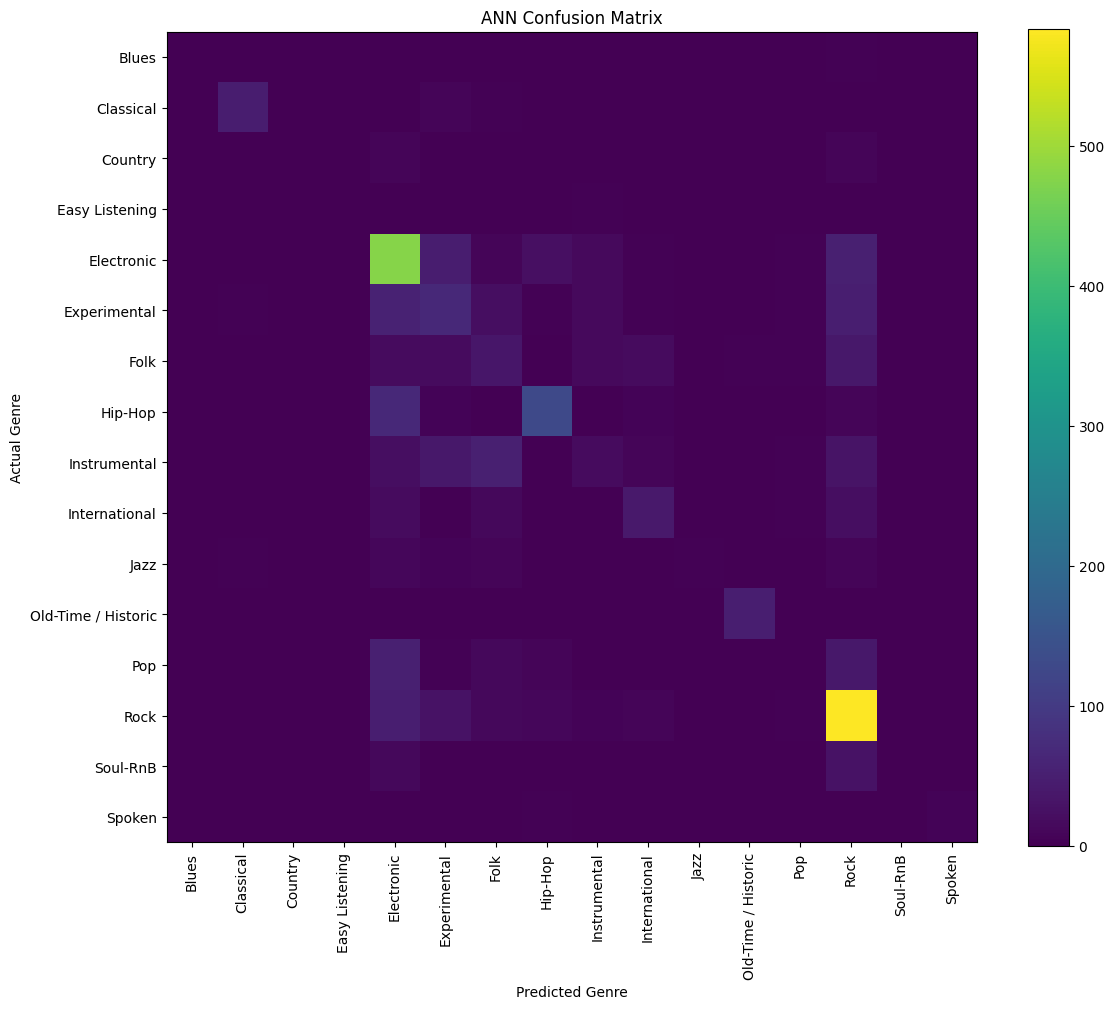

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_true_labels,
    all_predictions
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=90
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
total_parameters = 0

for parameter in model.parameters():

    total_parameters += parameter.numel()

print("Total trainable parameters:", total_parameters)

Total trainable parameters: 19664


In [ ]:
import os
import joblib

ANN_MODEL_DIR = "/content/drive/MyDrive/music-genre-capstone/models/ann"

os.makedirs(ANN_MODEL_DIR, exist_ok=True)

# Save the best ANN model
model_path = os.path.join(
    ANN_MODEL_DIR,
    "best_ann_model.pth"
)

torch.save(
    model.state_dict(),
    model_path
)

# Save the scaler used for ANN features
scaler_path = os.path.join(
    ANN_MODEL_DIR,
    "ann_scaler.pkl"
)

joblib.dump(
    scaler,
    scaler_path
)

print("ANN model saved to:")
print(model_path)

print("\nScaler saved to:")
print(scaler_path)

ANN model saved to:
/content/drive/MyDrive/music-genre-capstone/models/ann/best_ann_model.pth

Scaler saved to:
/content/drive/MyDrive/music-genre-capstone/models/ann/ann_scaler.pkl


In [2]:
import os
import time
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cpu")
print("Using:", device)

PROJECT_ROOT = "/content/drive/MyDrive/music-genre-capstone"
FEATURE_ROOT = os.path.join(PROJECT_ROOT, "data", "features")

TRAIN_DIR = os.path.join(FEATURE_ROOT, "training_final")
VAL_DIR = os.path.join(FEATURE_ROOT, "validation_final")
TEST_DIR = os.path.join(FEATURE_ROOT, "test_final")

MODEL_DIR = os.path.join(PROJECT_ROOT, "models", "ann")
RESULT_DIR = os.path.join(PROJECT_ROOT, "results", "ann")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

print("Setup complete")

PyTorch: 2.11.0+cpu
CUDA available: False
Using: cpu
Setup complete


In [4]:
import os
import shutil

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

os.makedirs("/content/drive")

from google.colab import drive
drive.mount("/content/drive")

print("Drive connected:", os.path.exists(PROJECT_ROOT))
print("Train folder exists:", os.path.exists(TRAIN_DIR))
print("Model folder exists:", os.path.exists(MODEL_DIR))

Mounted at /content/drive
Drive connected: True
Train folder exists: True
Model folder exists: True


In [5]:
class ANNDataset(Dataset):
    def __init__(self, shard_paths, label_encoder):
        self.features = []
        self.labels = []

        for path in shard_paths:
            with np.load(path) as data:
                self.features.append(data["ann_features"])

                if "genre" in data:
                    labels = data["genre"]
                else:
                    labels = data["genres"]

                self.labels.extend(labels)

        self.features = np.concatenate(self.features, axis=0)
        self.labels = label_encoder.transform(self.labels)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.features[idx], dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


class_names = [
    "Blues", "Classical", "Country", "Easy Listening",
    "Electronic", "Experimental", "Folk", "Hip-Hop",
    "Instrumental", "International", "Jazz",
    "Old-Time / Historic", "Pop", "Rock",
    "Soul-RnB", "Spoken"
]

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(class_names)

train_shards = sorted([
    os.path.join(TRAIN_DIR, f)
    for f in os.listdir(TRAIN_DIR)
    if f.endswith(".npz")
])

val_shards = sorted([
    os.path.join(VAL_DIR, f)
    for f in os.listdir(VAL_DIR)
    if f.endswith(".npz")
])

test_shards = sorted([
    os.path.join(TEST_DIR, f)
    for f in os.listdir(TEST_DIR)
    if f.endswith(".npz")
])

train_dataset = ANNDataset(train_shards, label_encoder)
val_dataset = ANNDataset(val_shards, label_encoder)
test_dataset = ANNDataset(test_shards, label_encoder)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 19909
Validation: 2504
Test: 2572


In [6]:
class ANN(nn.Module):
    def __init__(self, input_size=80, num_classes=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.network(x)


model = ANN(input_size=80, num_classes=16).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

ANN(
  (network): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=16, bias=True)
  )
)
Parameters: 19664


In [7]:
checkpoint_path = "/content/drive/MyDrive/music-genre-capstone/models/ann/best_ann_model.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)

print(type(checkpoint))
print(checkpoint.keys() if isinstance(checkpoint, dict) else "Not a dictionary")

<class 'collections.OrderedDict'>
odict_keys(['network.0.weight', 'network.0.bias', 'network.2.weight', 'network.2.bias', 'network.4.weight', 'network.4.bias'])


In [8]:
model.load_state_dict(checkpoint)

print("ANN checkpoint loaded successfully.")

ANN checkpoint loaded successfully.


In [9]:
model.eval()

correct = 0
total = 0
running_loss = 0.0

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        running_loss += loss.item() * X.size(0)
        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

test_accuracy = 100 * correct / total
test_loss = running_loss / total

print(f"Checkpoint Test Accuracy: {test_accuracy:.2f}%")
print(f"Checkpoint Test Loss: {test_loss:.4f}")

Checkpoint Test Accuracy: 4.28%
Checkpoint Test Loss: 121.0973


In [10]:
X, y = next(iter(test_loader))

print("X shape:", X.shape)
print("X dtype:", X.dtype)
print("X mean:", X.mean().item())
print("X std:", X.std().item())
print("X min:", X.min().item())
print("X max:", X.max().item())
print("y shape:", y.shape)
print("First 10 labels:", y[:10].tolist())

X shape: torch.Size([32, 80])
X dtype: torch.float32
X mean: 5.159627914428711
X std: 18.097232818603516
X min: -190.74880981445312
X max: 139.50559997558594
y shape: torch.Size([32])
First 10 labels: [13, 13, 13, 9, 9, 9, 9, 9, 9, 14]


In [11]:
print("Checking available variables related to scaling/normalization:")

for name in dir():
    if any(word in name.lower() for word in ["scal", "mean", "std", "normal"]):
        try:
            value = eval(name)
            print(name, type(value), end=": ")
            print(value if not hasattr(value, "shape") else f"shape={value.shape}")
        except:
            pass

Checking available variables related to scaling/normalization:
StandardScaler <class 'type'>: <class 'sklearn.preprocessing._data.StandardScaler'>


In [12]:
print("Train sample:")
print(train_dataset[0])

print("\nDataset types:")
print("Train:", type(train_dataset))
print("Val:", type(val_dataset))
print("Test:", type(test_dataset))

Train sample:
(tensor([-66.7606,  64.2582,  -9.7898,  11.3082,  -2.3992,   9.0463,  -1.1240,
          4.5561,  -5.2958,   0.2409,  -9.4897,   2.5836,  -2.2000,   7.4033,
         -2.5326,   0.4779,  -7.7234,  -2.7773,  -2.2288,  -0.6087,  -3.7493,
         -1.1369,  -2.7092,   0.7249,   0.0717,   4.9557,  -0.3671,   6.4952,
          4.2043,  -0.3485,  -4.6030,   4.6045,  -0.1182,   5.4174,  -0.7135,
          0.5460,  -2.8465,  -1.6922,  -0.5901,   1.0614,  54.0602,  30.4590,
         22.8188,  17.7067,  17.5440,  13.8263,  12.5158,   9.4060,  10.2697,
          8.7240,   9.5776,  10.5491,   8.8052,   7.8376,   7.3113,   7.0756,
          7.3094,   7.2273,   7.1923,   6.3651,   6.7792,   7.9584,   7.2727,
          8.7784,   8.0630,   7.2806,   7.3443,   8.9501,   7.9004,   8.1698,
          7.3353,   7.0537,   7.1502,   6.8562,   5.6020,   5.7607,   5.6428,
          5.7772,   6.3205,   5.5822]), tensor(7))

Dataset types:
Train: <class '__main__.ANNDataset'>
Val: <class '__main__.A

In [14]:
print("Train dataset attributes:")
print(train_dataset.__dict__.keys())

print("\nTrain dataset contents:")
for key, value in train_dataset.__dict__.items():
    if hasattr(value, "shape"):
        print(key, "shape =", value.shape)
    else:
        print(key, "type =", type(value))

Train dataset attributes:
dict_keys(['features', 'labels'])

Train dataset contents:
features shape = (19909, 80)
labels shape = (19909,)


In [15]:
scaler = StandardScaler()

# Fit ONLY on training data
train_dataset.features = scaler.fit_transform(train_dataset.features)

# Use the same scaler for validation and test
val_dataset.features = scaler.transform(val_dataset.features)
test_dataset.features = scaler.transform(test_dataset.features)

print("Train mean:", train_dataset.features.mean())
print("Train std:", train_dataset.features.std())

print("Val mean:", val_dataset.features.mean())
print("Val std:", val_dataset.features.std())

print("Test mean:", test_dataset.features.mean())
print("Test std:", test_dataset.features.std())

Train mean: 1.2789746e-09
Train std: 1.0
Val mean: -0.019078922
Val std: 1.005729
Test mean: -0.009325778
Test std: 1.0183882


In [16]:
model.eval()

correct = 0
total = 0
running_loss = 0.0

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        running_loss += loss.item() * X.size(0)

        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

test_accuracy = 100 * correct / total
test_loss = running_loss / total

print(f"Checkpoint Test Accuracy: {test_accuracy:.2f}%")
print(f"Checkpoint Test Loss: {test_loss:.4f}")

Checkpoint Test Accuracy: 56.69%
Checkpoint Test Loss: 1.5124


In [17]:
num_epochs = 50

best_val_acc = 0.0
best_epoch = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("Starting from saved best checkpoint.")
print("Target epochs:", num_epochs)

Starting from saved best checkpoint.
Target epochs: 50


In [18]:
for epoch in range(50):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)

        _, predicted = torch.max(outputs, 1)
        total += y.size(0)
        correct += (predicted == y).sum().item()

    train_loss = running_loss / total
    train_acc = 100 * correct / total

    # Validation
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            val_running_loss += loss.item() * X.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += y.size(0)
            val_correct += (predicted == y).sum().item()

    val_loss = val_running_loss / val_total
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

        torch.save(
            model.state_dict(),
            "/content/drive/MyDrive/music-genre-capstone/models/ann/best_ann_extended_model.pth"
        )

    print(
        f"Epoch {epoch+1:02d}/50 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

print(f"\nBest extended validation accuracy: {best_val_acc:.2f}%")
print(f"Best extended epoch: {best_epoch}")

Epoch 01/50 | Train Loss: 1.1140 | Train Acc: 64.33% | Val Loss: 1.2759 | Val Acc: 62.14%
Epoch 02/50 | Train Loss: 1.0931 | Train Acc: 65.00% | Val Loss: 1.2945 | Val Acc: 61.26%
Epoch 03/50 | Train Loss: 1.0696 | Train Acc: 65.71% | Val Loss: 1.3051 | Val Acc: 61.38%
Epoch 04/50 | Train Loss: 1.0482 | Train Acc: 66.18% | Val Loss: 1.3182 | Val Acc: 61.06%
Epoch 05/50 | Train Loss: 1.0234 | Train Acc: 66.82% | Val Loss: 1.3452 | Val Acc: 61.02%
Epoch 06/50 | Train Loss: 1.0030 | Train Acc: 67.49% | Val Loss: 1.3427 | Val Acc: 59.38%
Epoch 07/50 | Train Loss: 0.9841 | Train Acc: 68.31% | Val Loss: 1.3616 | Val Acc: 60.54%
Epoch 08/50 | Train Loss: 0.9624 | Train Acc: 68.49% | Val Loss: 1.3712 | Val Acc: 60.30%
Epoch 09/50 | Train Loss: 0.9428 | Train Acc: 69.31% | Val Loss: 1.4027 | Val Acc: 60.14%
Epoch 10/50 | Train Loss: 0.9234 | Train Acc: 69.97% | Val Loss: 1.4287 | Val Acc: 59.50%
Epoch 11/50 | Train Loss: 0.9099 | Train Acc: 70.50% | Val Loss: 1.4687 | Val Acc: 59.42%
Epoch 12/5

In [19]:
best_extended_path = "/content/drive/MyDrive/music-genre-capstone/models/ann/best_ann_extended_model.pth"

model.load_state_dict(torch.load(best_extended_path, map_location=device))
model.eval()

correct = 0
total = 0
running_loss = 0.0

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        y = y.to(device)

        outputs = model(X)
        loss = criterion(outputs, y)

        running_loss += loss.item() * X.size(0)

        _, predicted = torch.max(outputs, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

test_accuracy = 100 * correct / total
test_loss = running_loss / total

print(f"Extended ANN Test Accuracy: {test_accuracy:.2f}%")
print(f"Extended ANN Test Loss: {test_loss:.4f}")

Extended ANN Test Accuracy: 55.79%
Extended ANN Test Loss: 1.5562


In [20]:
import os

ann_dir = "/content/drive/MyDrive/music-genre-capstone/models/ann"

print("ANN model files:")
for file in os.listdir(ann_dir):
    print("-", file)

ANN model files:
- best_ann_model.pth
- ann_scaler.pkl
- best_ann_extended_model.pth
